# Exercise 4 - Discrete Fourier Analysis and Synthesis of Signals

## Objectives
- To learn that any periodic signal can be constructed using a linear combination of sinusoidal waves
- To introduce the Discrete Fourier Transform (DFT)
- To understand the difference between amplitude and phase in the frequency-domain 



In [25]:
import os
os.makedirs('results/ex4', exist_ok=True)

## Lab Exercise

### Sinusoidal Signals
We have seen how Python can manipulate data stored as a $1\times128$ vector. Now let us create a matrix `S` containing 10 rows of sine waves such that the first row is frequency $f$, the second row is the second harmonic $2f$ and so on. In this case, `Nsamp` = 128, `fsig` = 1000 and `fsamp` = 25600.

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from functions.lab_functions import sinegen

fs = 8000
fsig = 150
Nsamp = 100


S = []
for i in np.arange(0, 10):
    t, x = sinegen(fs, (i+1)*fsig, Nsamp)
    S.append(x)

Next, let us explore what happens when we add all the harmonics together. This can be done by first creating a row vector `p` containing 'ones', and then multiplying this with the matrix `S`:

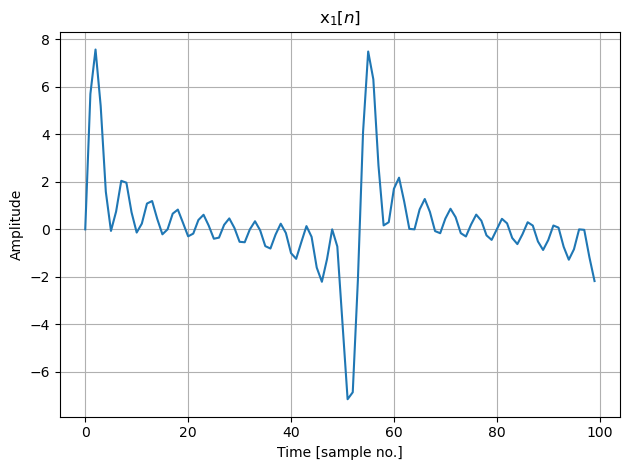

In [27]:
from functions.lab_functions import plot_signal

p = np.ones(10)
x1 = p.dot(S)

plt = plot_signal(x1, title='x$_1[n]$', xlabel='Time [sample no.]', ylabel='Amplitude')
plt.show()

>**GTA Tip**:
>
>The `np.dot(a, b)` command performs the dot product of two arrays. 

This is equivalent to calculating:
$$x_1[n]=\sum_{k=1}^{10}\sin(k \Omega n),$$

where $\Omega=2\pi\frac{f}{f_s}$ is the normalised angular fundamental frequency and $n=\{0,\:1,\:2,\cdots,\:\text{Nsamp}-1\}$.




**Question 4.1**: Explain the result $x_1[n]$.




$x_1[n]$ 是 10 个谐波关系正弦波的等权叠加。由于所有频率分量都是基频 $f$ = 150 Hz 的整数倍,合成信号的周期等于基频周期。最高谐波 1500 Hz 远低于 Nyquist 频率(4000 Hz),因此不会发生混叠。波形不再是简单正弦,而是呈现出 每个基频周期内有一个尖锐主峰加上若干小幅振荡 的形状。这是因为各谐波在主峰处相位对齐相加,在其他位置部分相消。这一现象说明:多个谐波正弦的线性组合可以构造出非正弦的周期信号,为后续用不同权重 $b[k]$ 合成方波、锯齿波等任意周期波形做了铺垫。

Instead of using a unity row vector, we could choose a different weight $b[k]$ for each harmonic component in the summation:
$$x_2[n]=\sum_{k=1}^{10}b[k]\sin(k \Omega n).$$

**Question 4.2** Try $b[k] = \big[1,\: 0,\: 1/3,\: 0,\: 1/5,\: 0,\: 1/7,\: 0,\: 1/9,\: 0\big]$ and observe what we get.

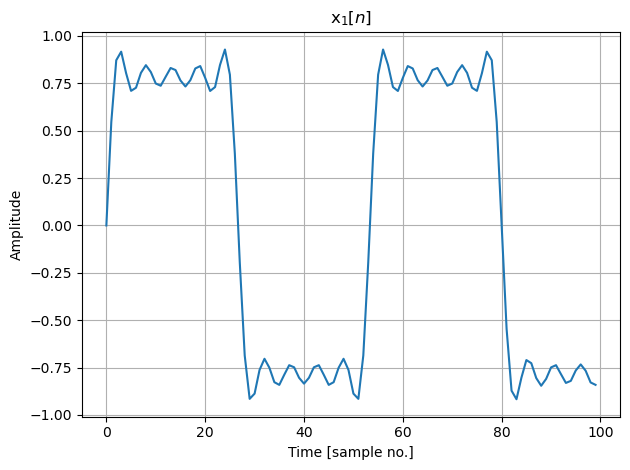

In [28]:
# add code here
b = [1, 0, 1/3, 0, 1/5, 0, 1/7, 0, 1/9, 0]
def plot_ex4(b):
    fs = 8000
    fsig = 150
    Nsamp = 100


    S = []
    for i in np.arange(0, 10):
        t, x = sinegen(fs, (i+1)*fsig, Nsamp)
        S.append(b[i] * x)
        
        
    p = np.ones(10)
    x1 = p.dot(S)

    plt = plot_signal(x1, title='x$_1[n]$', xlabel='Time [sample no.]', ylabel='Amplitude')
    plt.show()

plot_ex4(b)

> **Answer 4.2**:
>
> With $b[k] = [1,\,0,\,1/3,\,0,\,1/5,\,0,\,1/7,\,0,\,1/9,\,0]$ — only **odd** harmonics, weighted by $1/k$ — $x_2[n]$ approximates a **square wave**. This matches the well-known Fourier series:
>
> $$x_{\text{square}}[n] = \frac{4}{\pi}\sum_{k=1,3,5,\ldots}\frac{1}{k}\sin(k\Omega n).$$
>
> The visible ripples on the flat tops are **Gibbs oscillations**, caused by truncating the infinite series after the 9th harmonic. The signal passes through zero at $n=0$ and is **odd-symmetric**, since it is built entirely from sines.

**Question 4.3** Let us see what we get for $x_2[n]$ with $b[k] = \big[1,\: -1/2,\: 1/3,\: -1/4,\: 1/5,\: -1/6,\: 1/7,\: -1/8,\: 1/9, \:0\big]$.

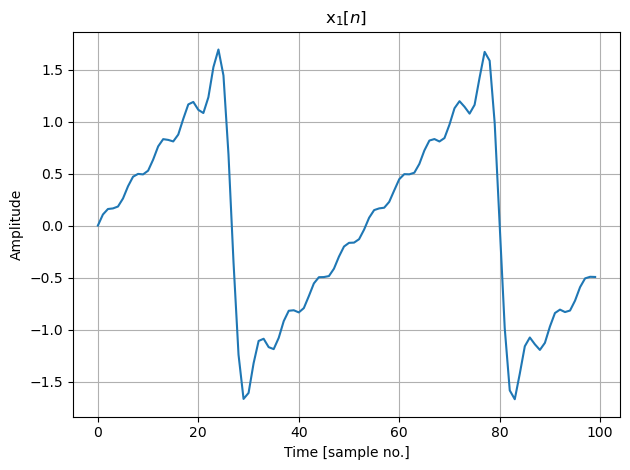

In [29]:
# add code here
b = [1, -1/2, 1/3, -1/4, 1/5, -1/6, 1/7, -1/8, 1/9, 0]
plot_ex4(b)

> **Answer 4.3**:
>
> With $b[k] = (-1)^{k+1}/k$ for $k=1,\ldots,9$, $x_2[n]$ approximates a **sawtooth wave**:
>
> $$x_{\text{saw}}[n] = 2\sum_{k=1}^{\infty}\frac{(-1)^{k+1}}{k}\sin(k\Omega n).$$
>
> Compared with Q4.2, **all** harmonics now contribute (not just odd ones), and the alternating signs produce the characteristic linear ramp followed by an abrupt drop. The signal remains odd-symmetric (sine-only construction).

**Question 4.4 (Optional)**: You may want to derive the results for $x_2[n]$ with $b[k] = \big[1,\: -1/2,\: 1/3,\: -1/4,\: 1/5,\: -1/6,\: 1/7,\: -1/8,\: 1/9, \:0\big]$ from first principles.


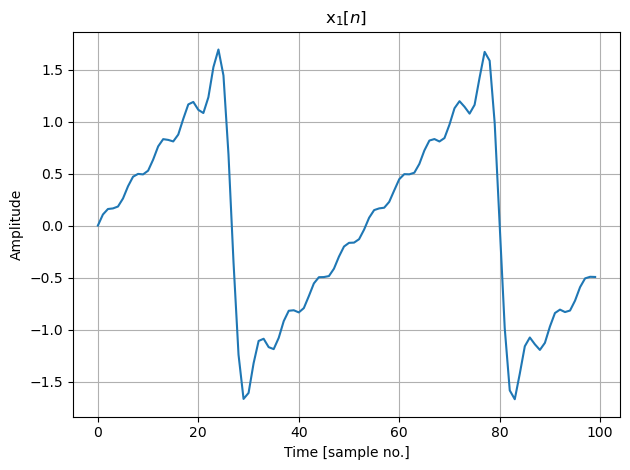

In [30]:
b = [1, -1/2, 1/3, -1/4, 1/5, -1/6, 1/7, -1/8, 1/9, 0]
plot_ex4(b)

So far, we have used sine waves as basis functions. Let us now try using cosine signals. First, create a `cosgen` function and use it to generate a $10\times 128$ matrix `C` with 10 harmonically-related cosine waveforms. 


**Question 4.5** Now, use the weight vector $a[k] = \big[1,\: 0,\: -1/3,\: 0,\: 1/5,\: 0,\:  -1/7,\: 0,\: 1/9,\: 0\big]$, to compute `x3=ak*C` and plot the result of:
$$x_3[n]=\sum_{k=1}^{10}a[k]\cos(k \Omega n).$$

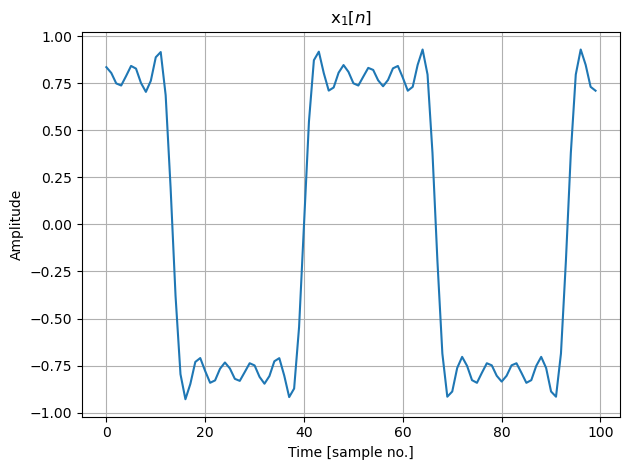

In [31]:
# add code here
from functions.lab_functions import cosgen

b = [1, 0, -1/3, 0, 1/5, 0, -1/7, 0, 1/9, 0]

fs = 8000
fsig = 150
Nsamp = 100


S = []
for i in np.arange(0, 10):
    t, x = cosgen(fs, (i+1)*fsig, Nsamp)
    S.append(b[i] * x)
    
    
p = np.ones(10)
x1 = p.dot(S)

plt = plot_signal(x1, title='x$_1[n]$', xlabel='Time [sample no.]', ylabel='Amplitude')
plt.show()

> **Answer 4.5**:
>
> With $a[k] = [1,\,0,\,-1/3,\,0,\,1/5,\,0,\,-1/7,\,0,\,1/9,\,0]$ applied to **cosines**, $x_3[n]$ is a **square wave** of the same shape and amplitude as $x_2[n]$ in Q4.2 — the cosine form of the square-wave series:
>
> $$x_3[n] = \frac{4}{\pi}\sum_{k=1,3,5,\ldots}\frac{(-1)^{(k-1)/2}}{k}\cos(k\Omega n).$$
>
> Crucially, $x_3[n]$ now starts at its **maximum value** at $n=0$ and is **even-symmetric**, since it is built entirely from cosines.

**Question 4.6**: How does $x_3[n]$ differ from $x_2[n]$ obtained earlier using sine waves? What general conclusions on the even and odd symmetry of the signal can you draw?

> **Answer 4.6**:
>
> $x_3[n]$ has the **same square-wave shape** as $x_2[n]$ but is shifted by a **quarter period (90°)**:
>
> | | $x_2[n]$ (Q4.2, sines) | $x_3[n]$ (Q4.5, cosines) |
> |---|---|---|
> | Value at $n=0$ | $0$ (zero crossing) | maximum (peak) |
> | Symmetry | **odd** ($x[-n]=-x[n]$) | **even** ($x[-n]=x[n]$) |
>
> **General conclusions on symmetry:**
> 1. Sine is odd ⇒ a sum of sines produces an **odd-symmetric** signal.
> 2. Cosine is even ⇒ a sum of cosines produces an **even-symmetric** signal.
> 3. Any periodic signal can be uniquely decomposed into an even part (cosines) and an odd part (sines):
>    $$x[n] = a[0] + \sum_{k\ge 1} a[k]\cos(k\Omega n) + \sum_{k\ge 1} b[k]\sin(k\Omega n).$$
>    - If $x[n]$ is **even** ⇒ all $b[k]=0$ (cosines only).
>    - If $x[n]$ is **odd** ⇒ all $a[k]=0$ (sines only).
>    - General signals require both, which motivates the complex-exponential form $\sum A[k]e^{jk\Omega n}$ (Q4.7), where the complex coefficient $A[k]$ encodes both magnitude and phase.

**Question 4.7 (Optional)**:  Prove that $x[n]=a[0] + \sum^{\infty}_{k=1}a[k]\cos(\frac{2\pi}{N}kn) + \sum^{\infty}_{k=1}b[k]\sin(\frac{2\pi}{N}kn)$ is equivalent to $x[n]=\sum^{\infty}_{k=-\infty}A[k]e^{j\frac{2\pi}{N}kn}$. How can the coefficients $A[k]$ be determined? 

>**GTA Tip**
>
>Recall that $\sin(\theta) = -\frac{1}{2}je^{j\theta} + \frac{1}{2}je^{-j\theta}$ and $\cos(\theta) = \frac{1}{2}e^{j\theta}+ \frac{1}{2}e^{-j\theta}$.

> **Answer 4.7 (Optional)**:
>
> Let $\omega_0 = 2\pi/N$. We want to show that the **trigonometric form**
> $$x[n] = a[0] + \sum_{k=1}^{\infty} a[k]\cos(k\omega_0 n) + \sum_{k=1}^{\infty} b[k]\sin(k\omega_0 n) \tag{1}$$
> is equivalent to the **complex-exponential form**
> $$x[n] = \sum_{k=-\infty}^{\infty} A[k] e^{jk\omega_0 n}. \tag{2}$$
>
> **Step 1 — Substitute Euler's identities.** From the GTA tip,
> $$\cos(k\omega_0 n) = \tfrac{1}{2}\bigl(e^{jk\omega_0 n} + e^{-jk\omega_0 n}\bigr), \qquad \sin(k\omega_0 n) = -\tfrac{j}{2}\bigl(e^{jk\omega_0 n} - e^{-jk\omega_0 n}\bigr).$$
>
> Plug these into the $k$-th term of (1):
> $$a[k]\cos(k\omega_0 n) + b[k]\sin(k\omega_0 n) = \frac{a[k]-jb[k]}{2}\,e^{jk\omega_0 n} \;+\; \frac{a[k]+jb[k]}{2}\,e^{-jk\omega_0 n}.$$
>
> **Step 2 — Re-index the negative-frequency part.** Define
> $$A[0] = a[0], \qquad A[k] = \frac{a[k]-jb[k]}{2}\ \ (k>0), \qquad A[-k] = \frac{a[k]+jb[k]}{2}\ \ (k>0).$$
>
> Then (1) becomes
> $$x[n] = A[0] + \sum_{k=1}^{\infty} A[k]\,e^{jk\omega_0 n} + \sum_{k=1}^{\infty} A[-k]\,e^{-jk\omega_0 n}.$$
>
> Letting $m=-k$ in the last sum (so $m$ runs from $-\infty$ to $-1$):
> $$x[n] = \sum_{k=-\infty}^{\infty} A[k]\,e^{jk\omega_0 n},$$
> which is exactly (2). ∎
>
> **Step 3 — Conjugate symmetry (real signals).** For a real-valued signal, $a[k]$ and $b[k]$ are real, so
> $$\boxed{\,A[-k] = A[k]^*\,}$$
> i.e. the spectrum is **Hermitian-symmetric**. This is why the DFT of a real signal has $|X[k]|$ symmetric and $\angle X[k]$ antisymmetric about $k=N/2$.
>
> **Step 4 — How to determine $A[k]$.** The complex exponentials $\{e^{jk\omega_0 n}\}$ are orthogonal over one period:
> $$\frac{1}{N}\sum_{n=0}^{N-1} e^{j(k-k')\omega_0 n} = \delta[k-k'].$$
>
> Multiplying both sides of (2) by $e^{-jk'\omega_0 n}$ and summing over one period extracts the coefficient:
> $$\boxed{\;A[k] = \frac{1}{N}\sum_{n=0}^{N-1} x[n]\,e^{-jk\omega_0 n}.\;}$$
>
> This is the **DFS analysis equation** (and equals $X[k]/N$ using the DFT convention defined later in this notebook, where $X[k]=\sum_n x[n]e^{-jk\omega_0 n}$ without the $1/N$ factor).
>
> **Interpretation.** The single complex coefficient $A[k]$ replaces the pair $(a[k], b[k])$:
> - $|A[k]|$ encodes the **magnitude** of the $k$-th harmonic,
> - $\angle A[k]$ encodes its **phase**.
>
> This is precisely why the complex-exponential form is preferred for the DFT/DFS — it unifies the cosine (even) and sine (odd) decompositions of Q4.5 and Q4.6 into a single compact representation.

We observe a really important property of periodic signals using Fourier series analysis. Fourier series analysis states that any periodic function can be constructed using a weighted sum of harmonically-related sinusoids. This leads to the definition of the Discrete Fourier Series (DFS) for periodic signals:

---
**DFS (Discrete Fourier Series)**:
$$\text{Forward Transform: }X[k]=\sum^{N-1}_{n=0}x[n]e^{-j \frac{2\pi}{N} kn}, \quad k = 0,\pm1,\pm2,\cdots$$
$$\text{ Inverse Transform: }x[n]= \frac{1}{N}\sum^{N-1}_{k=0} X[k]e^{j \frac{2\pi}{N} kn} , \quad n = 0,\pm1,\pm2,\cdots$$

---

You should now be able to see that it is possible to construct $x[n]$ from a finite number of harmonics; the frequencies are $\Omega=\frac{2\pi}{N}k,$ where $k = 0, 1,\cdots,N-1$.

**Question 4.8**:  Derive the DFS of the periodic sequence  $x[n] = \{\cdots, \stackrel{\text{n=0}}{0}, \stackrel{}{1}, \stackrel{}{2}, \stackrel{}{3}, \stackrel{}{0}, \stackrel{}{1}, \stackrel{}{2}, \stackrel{}{3}, \stackrel{}{0}, \stackrel{}{1}, \stackrel{}{2}, \stackrel{}{3},\cdots\}$, where $N=4$ and the '$n=0$' denotes the $0^{\text{th}}$ sample. What do you notice about the periodicity of $X[k]$? 

DFS coefficients (one period):
  X[0] = (6+0j)
  X[1] = (-2+2j)
  X[2] = (-2-0j)
  X[3] = (-2-2j)

Verified by scipy.fft.fft : [ 6.-0.j -2.+2.j -2.-0.j -2.-2.j]


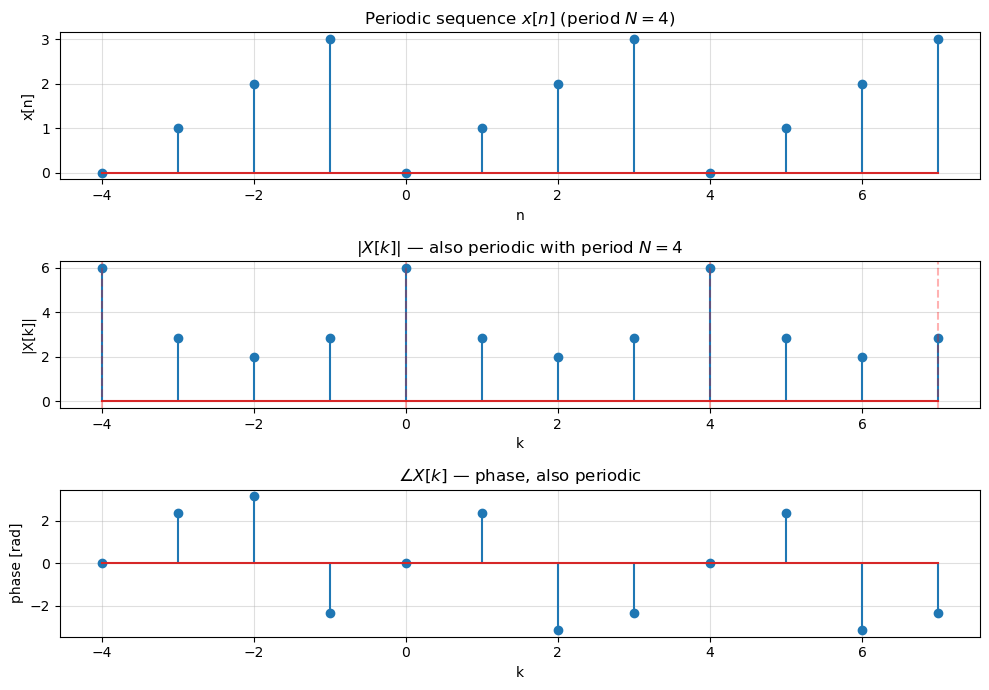

In [52]:
# Q4.8: DFS of the periodic sequence x[n] = {..., 0, 1, 2, 3, 0, 1, 2, 3, ...} with N=4
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft

# One period of x[n] (n = 0, 1, 2, 3)
x_period = np.array([0, 1, 2, 3])
N = len(x_period)

# --- Direct DFS computation: X[k] = sum_{n=0}^{N-1} x[n] e^{-j 2pi k n / N}  ---
n = np.arange(N)
def X(k):
    return np.sum(x_period * np.exp(-1j * 2*np.pi/N * k * n))

print('DFS coefficients (one period):')
for k in range(N):
    print(f'  X[{k}] = {np.round(X(k), 4)}')

# Verify against scipy.fft.fft (which implements the same forward sum)
print('\nVerified by scipy.fft.fft :', np.round(fft(x_period), 4))

# --- Show periodicity of X[k]: evaluate over k = -N .. 2N-1 ---
k_range = np.arange(-N, 2*N)
X_vals = np.array([X(k) for k in k_range])

# Show periodicity of x[n]: tile 3 periods
x_extended = np.tile(x_period, 3)
n_extended = np.arange(-N, 2*N)

fig, axes = plt.subplots(3, 1, figsize=(10, 7))

axes[0].stem(n_extended, x_extended)
axes[0].set_title('Periodic sequence $x[n]$ (period $N=4$)')
axes[0].set_xlabel('n'); axes[0].set_ylabel('x[n]')
axes[0].grid(True, alpha=0.4)

axes[1].stem(k_range, np.abs(X_vals))
axes[1].set_title('$|X[k]|$ — also periodic with period $N=4$')
axes[1].set_xlabel('k'); axes[1].set_ylabel('|X[k]|')
for kk in [-N, 0, N, 2*N-1]:
    axes[1].axvline(kk, color='red', ls='--', alpha=0.3)
axes[1].grid(True, alpha=0.4)

axes[2].stem(k_range, np.angle(X_vals))
axes[2].set_title(r'$\angle X[k]$ — phase, also periodic')
axes[2].set_xlabel('k'); axes[2].set_ylabel('phase [rad]')
axes[2].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

> **Answer 4.8 (Analytical Derivation)**:
>
> One period of the signal is $\{x[0], x[1], x[2], x[3]\} = \{0, 1, 2, 3\}$ with $N=4$, so
> $\Omega_0 = 2\pi/N = \pi/2$ and the DFS analysis equation gives
>
> $$X[k] = \sum_{n=0}^{3} x[n]\, e^{-j\frac{\pi}{2}kn} = e^{-j\frac{\pi}{2}k} + 2 e^{-j\pi k} + 3 e^{-j\frac{3\pi}{2}k}.$$
>
> Evaluating for $k = 0, 1, 2, 3$:
>
> | $k$ | $X[k]$ | $\|X[k]\|$ | $\angle X[k]$ |
> |:---:|:---:|:---:|:---:|
> | 0 | $0+1+2+3 = 6$ | $6$ | $0$ |
> | 1 | $-j - 2 + 3j = -2 + 2j$ | $2\sqrt{2}$ | $3\pi/4$ |
> | 2 | $-1 + 2 - 3 = -2$ | $2$ | $\pi$ |
> | 3 | $j - 2 - 3j = -2 - 2j$ | $2\sqrt{2}$ | $-3\pi/4$ |
>
> **Periodicity of $X[k]$**: Substituting $k \to k + N$ in the DFS:
> $$X[k+N] = \sum_{n=0}^{N-1} x[n] e^{-j\frac{2\pi}{N}(k+N)n} = \sum_{n=0}^{N-1} x[n] e^{-j\frac{2\pi}{N}kn}\underbrace{e^{-j 2\pi n}}_{=1} = X[k].$$
>
> So **$X[k]$ is itself periodic with the same period $N=4$** as $x[n]$. The plot above confirms this: $X[-1] = X[3]$, $X[4] = X[0]$, etc.
>
> **Note on conjugate symmetry**: Because $x[n]$ is real, $X[-k] = X[k]^*$. You can see this in the table: $X[3] = X[-1] = X[1]^*$.
>
> **Why this matters**: This periodicity is the reason the DFS sum runs over only $N$ values of $k$ — there are only $N$ *distinct* harmonics $e^{jk\Omega_0 n}$ when $n$ is discrete.

It should be evident that $X[k]$ is itself a (complex-valued) periodic sequence with a fundamental period equal to $N$, that is,

$$X[k+N]=X[k],$$

where $k$ is the harmonic or frequency bin index and $n$ is the sample index.

Recall that to perform the frequency analysis of a periodic signal, we take one cycle and perform the DFS. So what about non-periodic signals? If an infinitely long continuous-time domain signal is sampled, the frequency-domain representation is given by what is called the Discrete-Time Fourier Transform (DTFT). This is defined as $X(e^{j\Omega})=\sum\limits_{n=-\infty}^{\infty}x[n]e^{-j\Omega n}$ and gives a continuous frequency-domain representation. 

However, it is not possible in practice to process an infinite number of samples. Therefore, we only take and analyse the frequency contents of a finite number of samples $N$ in practice. This leads to the Discrete Fourier Transform (DFT). The DFT is related to the DTFT via frequency-domain sampling at discrete frequencies $2\pi k/N$, $k = 0,1,\cdots N-1$ of the DTFT spectrum $X(e^{j\Omega})$, where $\Omega$ is the frequency-domain variable.

The equations for the Discrete Fourier Series (DFS) and the Discrete Fourier Transform (DFT) are surprisingly the same but the reasoning behind the periodicity is not. In the DFS, the time sequence is 'naturally' periodic whereas the periodicity of the DFT is enforced by frequency-domain sampling of $X(e^{j\Omega})$ (<em>recall Exercise 3 and the effects of sampling</em>). The full mathematical definition of the DFT is:

---
**DFT (Discrete Fourier Transform)**: $x[n] \rightarrow X[k]$
$$\text{Forward Transform: }X[k]=\sum^{N-1}_{n=0}x[n]e^{-j \frac{2\pi}{N} kn}, \quad k = 0, 1, 2,\cdots N-1 $$
$$\text{ Inverse Transform: }x[n]= \frac{1}{N}\sum^{N-1}_{k=0} X[k]e^{j \frac{2\pi}{N} kn} , \quad n = 0, 1, 2,\cdots N-1 $$

---

**Question 4.9**: Can the Fourier transform modify the energy of a signal?

> **Answer 4.9**: **No** — the Fourier transform does not modify the energy of a signal. The DFT is a *unitary* (orthogonal) basis change between the time-domain basis $\{\delta[n-m]\}$ and the frequency-domain basis $\{e^{jk\Omega n}\}$, and unitary transforms preserve norms. This is **Parseval's theorem** (for the DFT convention used in this notebook):
>
> $$\sum_{n=0}^{N-1}|x[n]|^2 \;=\; \frac{1}{N}\sum_{k=0}^{N-1}|X[k]|^2.$$
>
> The Fourier transform only **redistributes** energy across frequency bins — it neither creates nor destroys it. The $1/N$ factor on the right is a convention artefact (the $1/N$ has been placed in the inverse DFT rather than split symmetrically as $1/\sqrt{N}$ on each side).

**Question 4.10**: When applying Fourier analysis to a signal, under which circumstances should a DFS be employed and under which circumstances should a DFT be employed?

> In Python we use the `fft` function to calculate the DFT. The Fast Fourier Transform (FFT) is just a fast algorithm that is used to calculate the DFT. 

> **Answer 4.10**:
>
> - **Use DFS** when the signal is genuinely **periodic** with a known period $N$, and we observe samples over an integer number of periods. The periodicity of $X[k]$ then arises naturally from the periodicity of $x[n]$.
>
> - **Use DFT** when the signal is **finite-length** ($N$ samples), regardless of whether the underlying signal is periodic or aperiodic. The DFT is what computers actually compute, since the DTFT (which would be the strict transform for an aperiodic infinite-length signal) has a *continuous* frequency-domain representation $X(e^{j\Omega})$ that cannot be stored exactly. The DFT corresponds to **frequency-domain sampling of the DTFT** at $\Omega_k = 2\pi k/N$, which — by the time–frequency duality from Ex3 — implicitly enforces **periodicity in time**. In other words, the DFT treats the $N$ samples *as if* they were one period of a periodic signal.
>
> The forward and inverse formulas of DFS and DFT are **identical**; the distinction is conceptual:
> - DFS: time-domain periodicity is **inherent**.
> - DFT: time-domain periodicity is **implied** by frequency-domain sampling.
>
> In practice almost all real-world DSP uses the DFT (via the FFT algorithm), because we always work with finite-length sampled data.

Now let us find the DFT spectrum of the sine wave produced by running the following code:

In [53]:
from scipy.fft import fft

t, x_sin = sinegen(8000,1000,8)
A = fft(x_sin)

Let us plot the results:

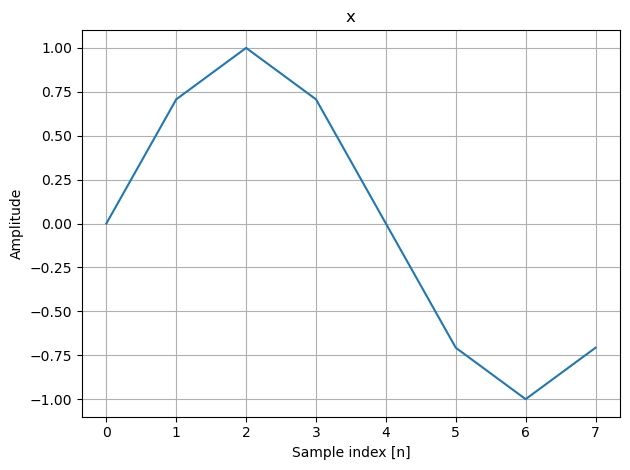

A: 
-0j
(-0-4j)
-0j
0j
-0j
-0j
0j
(-0+4j)


In [54]:
plt = plot_signal(x_sin, title='x', xlabel='Sample index [n]', ylabel='Amplitude')
plt.show()

print('A: ')
for i in A:
    print(np.round(i,1), end = '\n')

**Question 4.11**: Explain the numerical result in `A`. Make sure that you know the significance of each number in the output. Evaluate the DFT of a cosine signal. Is it what you would expect?



> **Answer 4.11**:
>
> **Setup**: $f_s=8000$ Hz, $f_{\text{sig}}=1000$ Hz, $N=8$ ⇒ frequency resolution $\Delta f = f_s/N = 1000$ Hz, and the signal contains exactly **one full period** in the 8 samples. The signal frequency falls precisely on bin $k=1$.
>
> **Expected output of `A`**:
>
> | $k$ | $A[k]$ | Frequency | Meaning |
> |:-:|:-:|:-:|---|
> | 0 | $0$ | DC | sine has zero mean |
> | 1 | $-4j$ | $+1000$ Hz | positive-frequency component |
> | 2–6 | $0$ | $2000\ldots 6000$ Hz | no energy at these bins |
> | 7 | $+4j$ | $-1000$ Hz (= $7000$ Hz mod $f_s$) | negative-frequency component |
>
> **Significance of each number**:
>
> 1. **Only $A[1]$ and $A[7]$ are non-zero** because Euler's formula expresses the sine as a difference of two complex exponentials at $\pm 1000$ Hz:
>    $$\sin\!\left(\tfrac{2\pi n}{N}\right) = \frac{1}{2j}\bigl(e^{j2\pi n/N} - e^{-j2\pi n/N}\bigr).$$
>    These two complex exponentials map exactly to bins $k=1$ and $k=N{-}1=7$.
>
> 2. **Pure imaginary values** $\pm 4j$: because $\sin\theta = -\tfrac{j}{2}e^{j\theta} + \tfrac{j}{2}e^{-j\theta}$, the DFT coefficients are imaginary. In general, *real sines* produce *imaginary, antisymmetric* spectra.
>
> 3. **Magnitude $N/2 = 4$**: the unnormalised DFT scales each bin by $N$, and the sine's energy is split equally between $+f$ and $-f$, giving $N/2$ per bin.
>
> 4. **Hermitian symmetry $A[7] = A[1]^*$**: because $x[n]$ is real, $A[N-k] = A[k]^*$. Verify: $(-4j)^* = +4j = A[7]$. This is why we normally only inspect the first $N/2$ bins.
>
> **DFT of a cosine of the same frequency** — see the next code cell. We expect:
> - $A[1] = A[7] = N/2 = 4$ (both **real**, **equal sign** ⇒ even-symmetric spectrum)
> - all other bins $0$
>
> This matches the Q4.6 conclusion: **cosine ⇒ real, even spectrum**; **sine ⇒ imaginary, odd spectrum**. The complex DFT unifies both symmetries into a single coefficient $A[k]$ that simultaneously encodes magnitude and phase.

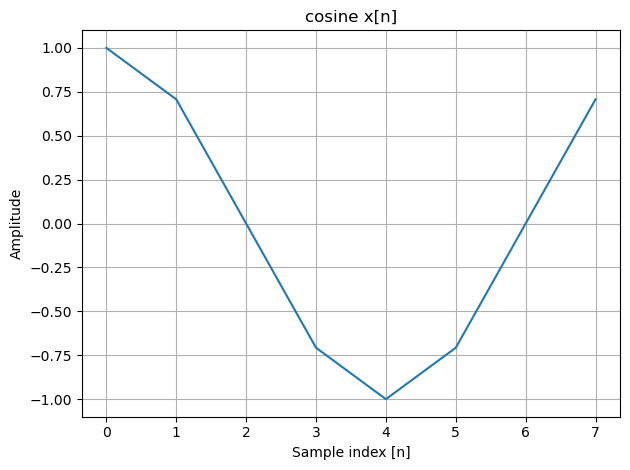

A (DFT of cosine):
(-0-0j)
(4-0j)
-0j
-0j
-0j
0j
0j
(4+0j)


In [55]:
# Q4.11: DFT of a cosine signal of the same frequency
from functions.lab_functions import cosgen

t, x_cos = cosgen(8000, 1000, 8)
A_cos = fft(x_cos)

plt = plot_signal(x_cos, title='cosine x[n]', xlabel='Sample index [n]', ylabel='Amplitude')
plt.show()

print('A (DFT of cosine):')
for i in A_cos:
    print(np.round(i, 1))


**Question 4.12**: What is the frequency resolution, $\Delta F$, of a 256-point DFT when the sampling frequency is 1000 Hz?

>**GTA Tip**
>
>- The first sample of the DFT represents the DC component (0 Hz). 
>- The last sample  of the DFT represents the sampling frequency minus the frequency resolution ($f_s - \Delta F$).


> **Answer 4.12**: The frequency resolution of an $N$-point DFT with sampling rate $f_s$ is
> $$\Delta f = \frac{f_s}{N}.$$
> For $N = 256$ and $f_s = 1000$ Hz:
> $$\Delta f = \frac{1000}{256} \approx 3.906\ \text{Hz}.$$
>
> **Why $f_s/N$?** The total observation window has length $T_{\text{obs}} = N/f_s$. By the time–frequency reciprocity, the finest resolvable frequency interval equals $1/T_{\text{obs}} = f_s/N$. Equivalently, the DFT implicitly assumes the $N$ samples form one period of a periodic signal whose fundamental frequency is exactly $f_s/N$, so all bins are integer multiples of that fundamental.

Instead of working with real and imaginary numbers of a complex number $A=b+jc$, where $b,c$ are real scalars and $j=\sqrt{-1}$, it is often more convenient to work with the magnitude and phase of the frequency components, as defined by:

>Magnitude, $|A|=\sqrt{b^2+c^2}$ and phase, $\angle{A}=\tan^{-1}\frac{c}{b}$.

We also define a `plot_spec(A)` function which plots the magnitude and phase spectra of `A`.

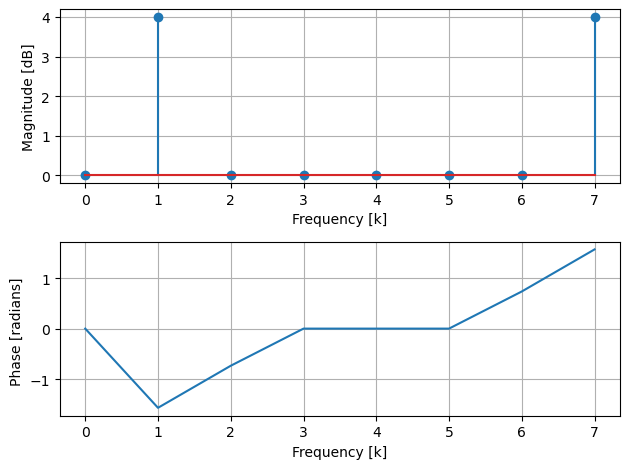

In [56]:
from functions.lab_functions import plot_spec

plt = plot_spec(A, func='stem')
plt.show()

### Dirac Delta and Rectangular Signals

Now, create a pulse signal with 8 samples of ones and 8 samples of zeros. Obtain its magnitude spectrum and verify that it is what you expect. 

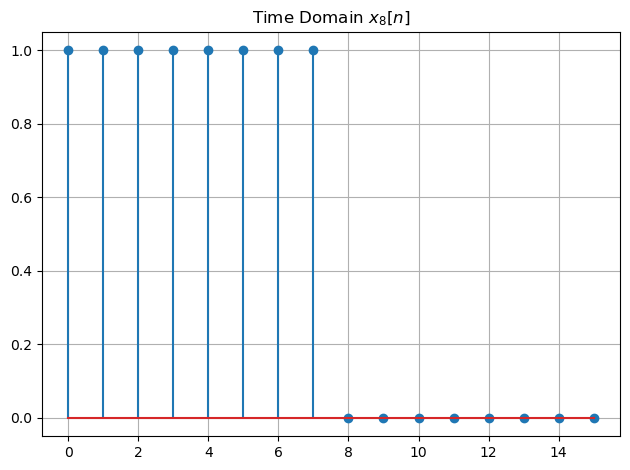

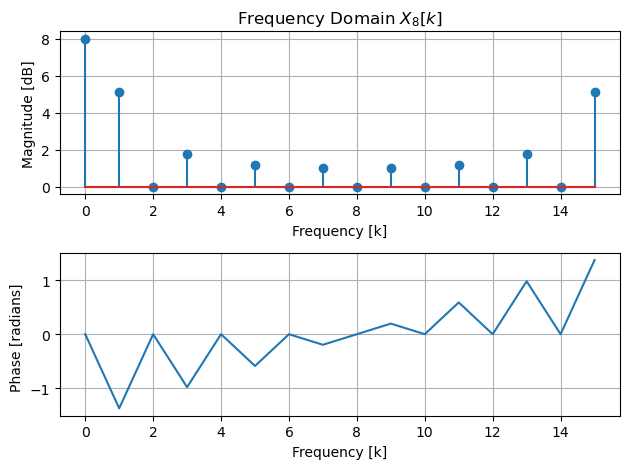

In [57]:
pulse_of_ones = np.ones(8) # Gradually reduce the width of the pulse until it becomes a unit impulse function
following_zeros = np.zeros(8)

x8 = np.concatenate((pulse_of_ones, following_zeros))
plt = plot_signal(x8, title='Time Domain $x_8[n]$', func='stem')
plt.show()

X8 = fft(x8);
plt = plot_spec(X8, title='Frequency Domain $X_8[k]$', func='stem')
plt.show()

Gradually reduce the width of the pulse until it becomes a unit impulse function, i.e. contains only a single one and 15 zeros. Observe the changes in the spectrum and make sure you can explain. 

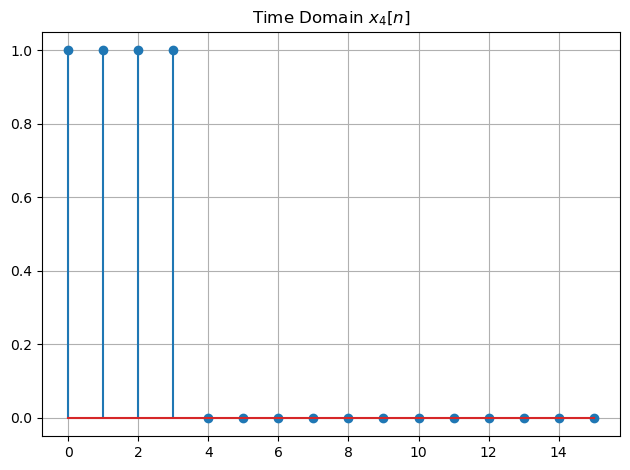

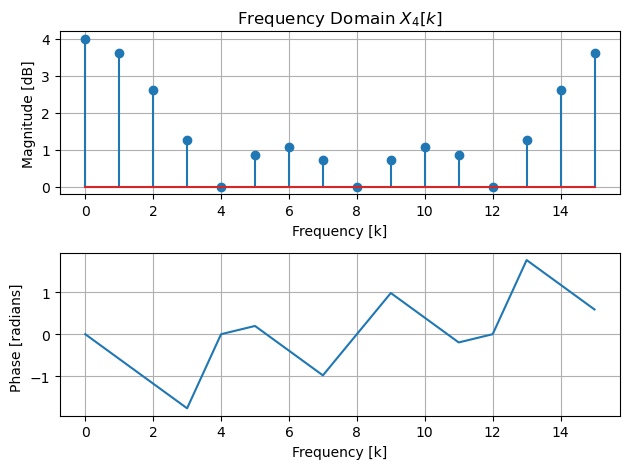

In [58]:
pulse_of_ones = np.ones(4) # Gradually reduce the width of the pulse until it becomes a unit impulse function
following_zeros = np.zeros(12)

x4 = np.concatenate((pulse_of_ones, following_zeros))
plt = plot_signal(x4, title='Time Domain $x_4[n]$', func='stem')
plt.show()

X4 = fft(x4);
plt = plot_spec(X4, title='Frequency Domain $X_4[k]$', func='stem')
plt.show()

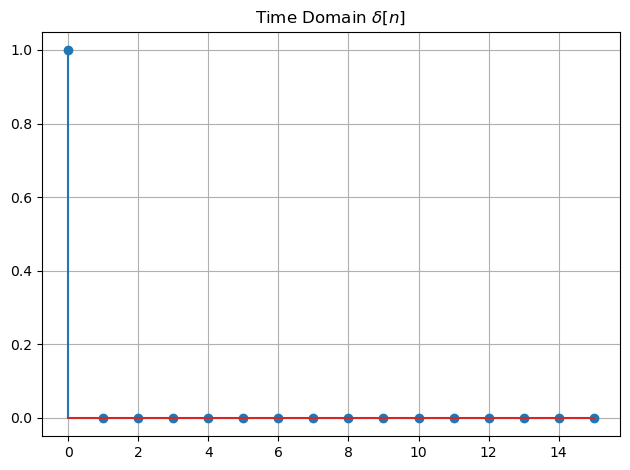

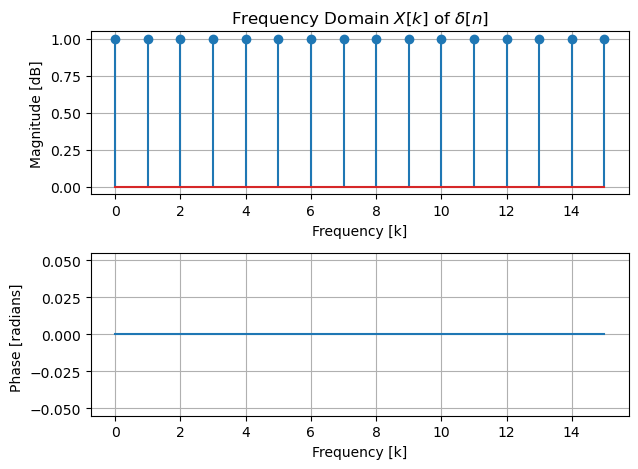

|X[k]| = [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
angle  = [-0.  0. -0.  0.  0.  0.  0.  0. -0. -0. -0. -0. -0. -0.  0. -0.]


In [59]:
# Limiting case: unit impulse (one '1' followed by 15 zeros)
unit_impulse = np.zeros(16)
unit_impulse[0] = 1   # delta[n]

plot_signal(unit_impulse, title=r'Time Domain $\delta[n]$', func='stem')
plt.show()

X_imp = fft(unit_impulse)
plot_spec(X_imp, title=r'Frequency Domain $X[k]$ of $\delta[n]$', func='stem')
plt.show()

print('|X[k]| =', np.round(np.abs(X_imp), 3))
print('angle  =', np.round(np.angle(X_imp), 3))


**Question 4.13**: What do these plots tell us about the frequency components that make up a unit impulse function?

Next, delay this unit impulse function by 1 sample and find its spectrum again. Examine the real and imaginary spectra. 

> **Answer 4.13 (Part 1 — frequency content of a unit impulse)**:
>
> The DFT of $\delta[n]$ is **completely flat**: $|X[k]| = 1$ and $\angle X[k] = 0$ for *every* $k$. Analytically,
> $$X[k] = \sum_{n=0}^{N-1}\delta[n]\,e^{-j\frac{2\pi}{N}kn} = e^{0} = 1\quad\text{for all }k.$$
>
> **Interpretation**: a unit impulse contains **all frequencies in equal amplitude and zero phase** — it is the discrete-time analogue of "white" content. This is the limiting case of the pulse-narrowing experiment:
>
> - 8-wide pulse ⇒ narrow main lobe + tall sidelobes
> - 4-wide pulse ⇒ broader main lobe + flatter sidelobes
> - 1-wide pulse (impulse) ⇒ **completely flat spectrum**
>
> This illustrates the **time–frequency duality / uncertainty principle**: the more concentrated a signal is in time, the more spread out it is in frequency. The impulse is the maximum time-concentration, and its spectrum is maximally spread (uniform).

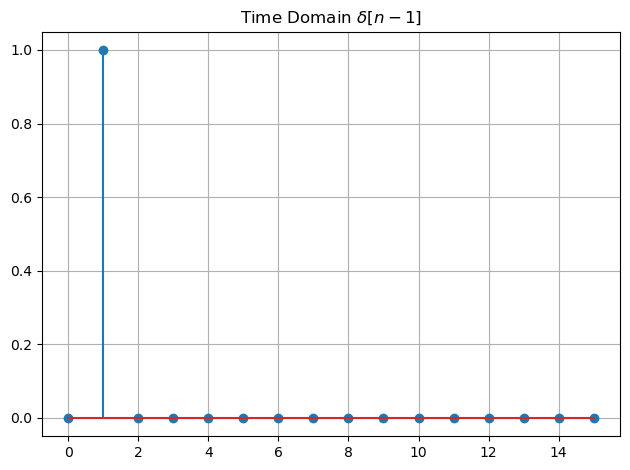

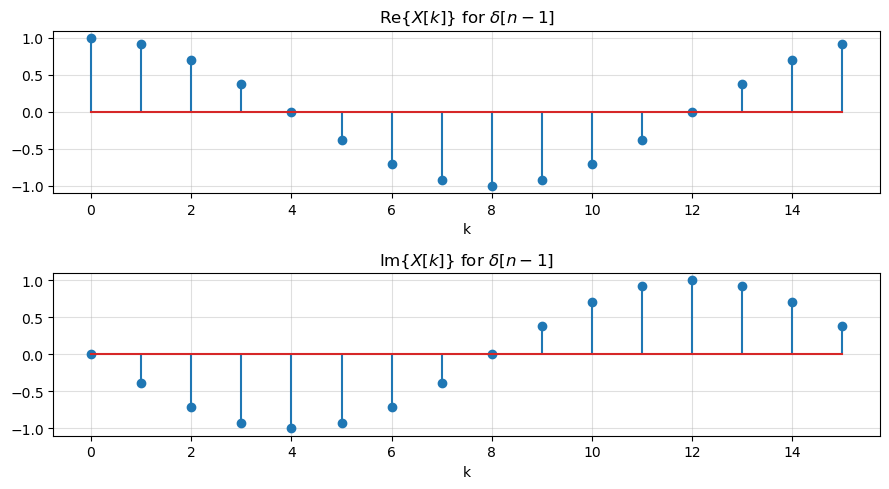

|X[k]| = [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
angle  = [-0.    -0.393 -0.785 -1.178 -1.571 -1.963 -2.356 -2.749 -3.142  2.749
  2.356  1.963  1.571  1.178  0.785  0.393]


In [60]:
# Q4.13 (Part 2): delay the unit impulse by 1 sample -> delta[n-1]
N = 16
delta_d = np.zeros(N)
delta_d[1] = 1   # impulse at n=1 instead of n=0

plot_signal(delta_d, title=r'Time Domain $\delta[n-1]$', func='stem')
plt.show()

X_d = fft(delta_d)

# Examine the real and imaginary spectra separately
fig, ax = plt.subplots(2, 1, figsize=(9, 5))
ax[0].stem(np.arange(N), np.real(X_d))
ax[0].set_title(r'Re$\{X[k]\}$ for $\delta[n-1]$')
ax[0].set_xlabel('k'); ax[0].grid(alpha=0.4)
ax[1].stem(np.arange(N), np.imag(X_d))
ax[1].set_title(r'Im$\{X[k]\}$ for $\delta[n-1]$')
ax[1].set_xlabel('k'); ax[1].grid(alpha=0.4)
plt.tight_layout(); plt.show()

# Also check magnitude and phase
print('|X[k]| =', np.round(np.abs(X_d), 3))
print('angle  =', np.round(np.angle(X_d), 3))


> **Answer 4.13 (Part 2 — delayed unit impulse)**:
>
> For $x[n] = \delta[n-1]$, the DFT is
> $$X[k] = \sum_{n=0}^{N-1}\delta[n-1]\,e^{-j\frac{2\pi}{N}kn} = e^{-j\frac{2\pi}{N}k}.$$
>
> **What changes vs the unit impulse**:
>
> | | $\delta[n]$ | $\delta[n-1]$ |
> |---|:-:|:-:|
> | $\|X[k]\|$ | $1$ for all $k$ (flat) | $1$ for all $k$ (still flat!) |
> | $\angle X[k]$ | $0$ for all $k$ | $-\dfrac{2\pi k}{N}$ — **linear in $k$** |
> | $\text{Re}\{X[k]\}$ | $1$ everywhere | $\cos(2\pi k/N)$ — cosine-shaped |
> | $\text{Im}\{X[k]\}$ | $0$ everywhere | $-\sin(2\pi k/N)$ — sine-shaped |
>
> **Key observation**: a time shift does **not** change the magnitude spectrum — the impulse still contains all frequencies in equal amplitude. The shift is encoded **entirely in the phase**, as a linear function of $k$. This is the **time-shift property** of the DFT:
> $$x[n - n_0] \;\longleftrightarrow\; X[k]\,e^{-j\frac{2\pi}{N}k n_0}.$$
>
> The detailed analysis of "delay by $n_0$ samples ⇒ phase slope $-2\pi n_0/N$" is the topic of Q4.14 below.

**Question 4.14**: What happens to the spectrum when the unit impulse function is delayed? What do you expect if you delay the impulse by 2 samples instead of 1? Investigate the phase of the delay (you may find the `np.unwrap` function useful).

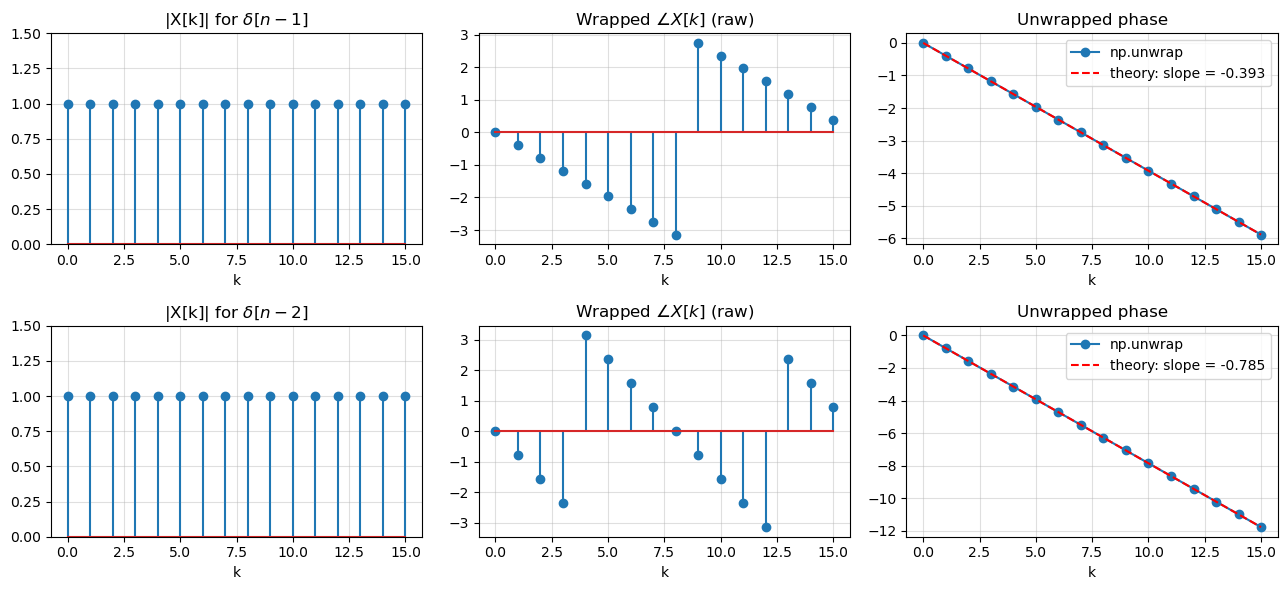

delay n0=1: theoretical slope = -0.3927, measured = -0.3927
delay n0=2: theoretical slope = -0.7854, measured = -0.7854


In [61]:
# Q4.14: investigate phase of impulses delayed by 1 and 2 samples
N = 16
k = np.arange(N)

fig, axes = plt.subplots(2, 3, figsize=(13, 6))

for row, n0 in enumerate([1, 2]):
    x = np.zeros(N)
    x[n0] = 1
    X = fft(x)

    # Magnitude
    axes[row, 0].stem(k, np.abs(X))
    axes[row, 0].set_title(rf'|X[k]| for $\delta[n-{n0}]$')
    axes[row, 0].set_xlabel('k'); axes[row, 0].grid(alpha=0.4)
    axes[row, 0].set_ylim(0, 1.5)

    # Wrapped (raw) phase
    axes[row, 1].stem(k, np.angle(X))
    axes[row, 1].set_title(r'Wrapped $\angle X[k]$ (raw)')
    axes[row, 1].set_xlabel('k'); axes[row, 1].grid(alpha=0.4)

    # Unwrapped phase + theoretical line
    phase_unwrapped = np.unwrap(np.angle(X))
    expected_slope = -2*np.pi*n0/N
    axes[row, 2].plot(k, phase_unwrapped, 'o-', label='np.unwrap')
    axes[row, 2].plot(k, expected_slope*k, 'r--', label=f'theory: slope = {expected_slope:.3f}')
    axes[row, 2].set_title('Unwrapped phase')
    axes[row, 2].set_xlabel('k'); axes[row, 2].legend(); axes[row, 2].grid(alpha=0.4)

plt.tight_layout()
plt.show()

# Print the slope estimates
for n0 in [1, 2]:
    x = np.zeros(N); x[n0] = 1
    phase_uw = np.unwrap(np.angle(fft(x)))
    measured_slope = (phase_uw[-1] - phase_uw[0]) / (N - 1)
    print(f'delay n0={n0}: theoretical slope = {-2*np.pi*n0/N:.4f}, measured = {measured_slope:.4f}')


> **Answer 4.14**:
>
> **What changes when the impulse is delayed?**
> The magnitude spectrum is **unchanged**: $|X[k]| = 1$ for all $k$, regardless of the delay $n_0$. Only the **phase** changes — and it changes in a very specific way.
>
> By the **time-shift property** of the DFT:
> $$x[n - n_0] \;\longleftrightarrow\; X[k]\,e^{-j\frac{2\pi}{N}k n_0}.$$
>
> Substituting $x[n] = \delta[n]$ (so $X[k] = 1$):
> $$\text{DFT}\{\delta[n - n_0]\} = e^{-j\frac{2\pi}{N}k n_0}.$$
>
> Therefore:
> - $|X[k]| = 1$ (flat)
> - $\angle X[k] = -\dfrac{2\pi n_0}{N}\,k$ — **a linear function of $k$ with slope $-\dfrac{2\pi n_0}{N}$**.
>
> **Effect of doubling the delay ($n_0 = 1 \to 2$)**:
>
> | Delay $n_0$ | Phase slope (rad/bin) | Numerical (N=16) |
> |:-:|:-:|:-:|
> | 1 | $-2\pi/N$ | $-0.393$ |
> | 2 | $-4\pi/N$ | $-0.785$ |
>
> Doubling the delay **doubles the slope** of the linear phase. This is exactly what the unwrapped-phase plot shows.
>
> **Why use `np.unwrap`?**
> The raw `np.angle` function returns phases in the principal range $(-\pi, \pi]$, so once the linear phase $-\frac{2\pi n_0}{N}k$ exceeds $-\pi$, the value "wraps" by adding $2\pi$ and the plot shows abrupt jumps (discontinuities). These jumps are an *artefact of the wrapping*, not a real change in the underlying phase. `np.unwrap` detects these jumps (any neighbouring difference larger than $\pi$) and adds the appropriate multiples of $2\pi$ to restore a smooth, monotonically decreasing line — making the linear-phase nature visible.
>
> **Key takeaway** — *time shift ⇔ linear phase*:
> A pure time delay is a **phase-only operation** in the frequency domain. The amplitude content of the signal is preserved exactly; only the relative phase relationships between frequency components are altered. This is why all-pass filters (which only change phase) can be used to delay or shape signals without changing their spectral magnitude.

### Real World Example: ECG Signals

To test how much you have understood so far, you are given a real electrocardiogram (EGC) signal. The signal contains 500 data samples and sampled at a rate of 200 Hz. Our aim is to detect the heart rate of the patient from which this ECG was taken.

We first load the data into a vector using the Python command:

In [62]:
from functions.lab_functions import load

ecg = load('files/ecg.mat', 'ecg')

Then, plot the ECG signal:

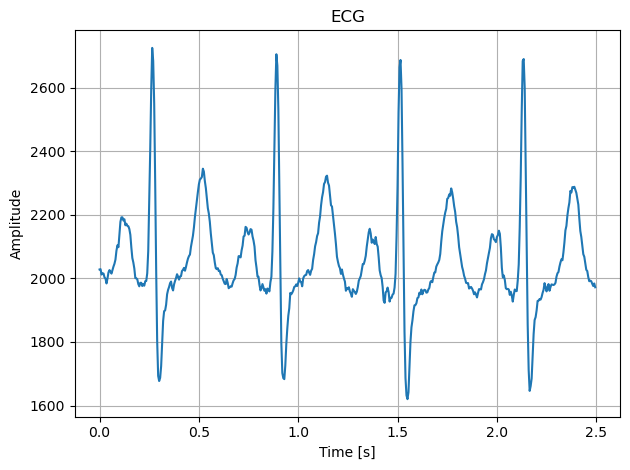

In [63]:
fsamp = 200;
Nsamp = len(ecg)
Tsamp = 1/fsamp
t = np.arange(0, Nsamp*Tsamp, Tsamp)
      
plt = plot_signal(t, ecg, title='ECG', xlabel='Time [s]', ylabel='Amplitude')
plt.show()

Now remove the DC component from the ECG signal by processing in the frequency-domain:

In [64]:
from scipy.fft import ifft

ECG = fft(ecg)
ECG[0] = 0 # remove the 0 Hz component 
ecg_no_dc = np.real(ifft(ECG))

**Question 4.15**: Can you think of a way of removing the DC component in the time domain without using the DFT? Try implementing this time-domain approach in Python.

In [65]:
# Q4.15: Remove the DC component in the TIME DOMAIN
# The DC component is just the mean of the signal -> subtract it
ecg_no_dc_td = ecg - np.mean(ecg)

# Verify equivalence with the frequency-domain version above
diff = np.max(np.abs(ecg_no_dc_td - ecg_no_dc))
print(f'Max |time-domain  -  freq-domain| = {diff:.2e}')
print(f'Mean of original ecg     = {np.mean(ecg):.4f}')
print(f'Mean of ecg_no_dc_td     = {np.mean(ecg_no_dc_td):.2e}  (should be ~0)')


Max |time-domain  -  freq-domain| = 4.55e-13
Mean of original ecg     = 2058.0260
Mean of ecg_no_dc_td     = 1.60e-13  (should be ~0)


> **Answer 4.15**:
>
> The **DC component** of a discrete signal is simply its **mean value**:
> $$\bar{x} = \frac{1}{N}\sum_{n=0}^{N-1} x[n].$$
>
> So in the time domain, removing the DC component is just:
> $$x_{\text{no DC}}[n] = x[n] - \bar{x}.$$
>
> **Why is this equivalent to setting $X[0]=0$?**
> The DFT bin $k=0$ is
> $$X[0] = \sum_{n=0}^{N-1} x[n]\,e^{-j 0} = \sum_{n=0}^{N-1} x[n] = N\bar{x}.$$
> Setting $X[0] = 0$ and taking the inverse DFT removes the constant $\bar{x}$ from every sample — exactly the same operation as subtracting the mean directly. The time-domain method is in fact more efficient (one subtraction vs an FFT + IFFT).

Let us plot the ECG signal with no DC offset:

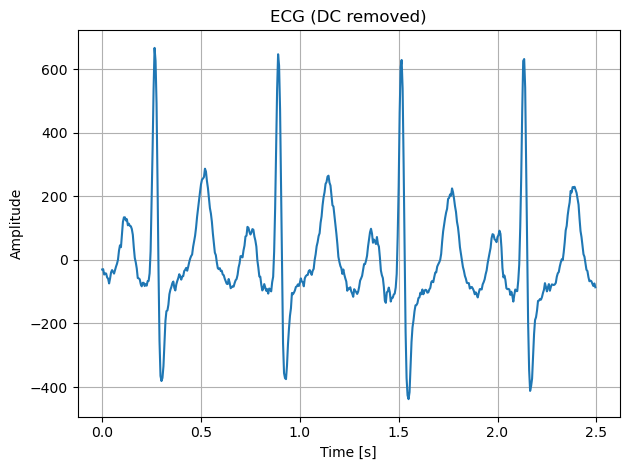

In [66]:
# Plot the ECG signal with the DC component removed
plot_signal(t, ecg_no_dc_td, title='ECG (DC removed)', xlabel='Time [s]', ylabel='Amplitude')
plt.show()


**Question 4.16**: Plot the spectra of the `ecg_no_dc` signal using the cell below. Make sure that you can interpret the frequency axis. Deduce the the person's heart rate in beats per minute. Does this result make sense when compared to your plot of `ecg_no_dc` in the time domain?

>**GTA Tip**
> A normal resting heart rate for adults ranges from 50 to 100 beats per minute.

Peaks: 
0.4
1.6
3.2
4.8
6.4
8.0
9.6
11.2
12.8
14.4
16.0
17.6
19.2


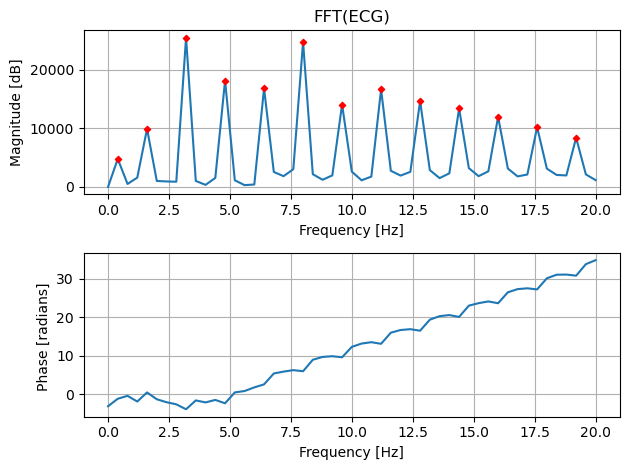

In [67]:
from functions.lab_functions import plot_spec_peaks

f_step = np.arange(0, fsamp, (fsamp/Nsamp))
y = fft(ecg_no_dc)

# Limit spectrum (zoom-in to the range)
f_max = 20 # Set the upper limit of the spectrum to 20 Hz
f_max_idx = np.argmax(f_step>f_max)
y = y[0:f_max_idx]
f_step = f_step[0:f_max_idx]

plt = plot_spec_peaks(f_step, y, title='FFT(ECG)')
plt.savefig('results/ex4/ex4_ecg.pdf')
plt.show()

>**GTA Tip**
>
>- The ECG signal is quasi-periodic and within each period, the heart cycles through both systole and diastole phases. In the frequency domain, you will not just see the heart rate, but also a series of successively higher frequencies called 'harmonic frequencies'. Therefore, to calculate the frequency of the heart, you first need to detect the multiple peaks generated in the frequency domain which will all be multiples of the fundamental frequency, $F_0$ (i.e. 1$^\text{st}$ peak = $F_0$; 2$^\text{nd}$ peak = $2\times F_0$;  3$^\text{rd}$ peak = $3\times F_0$; and so on). 
>
>
>- Note that the whole ECG signal contains 4 cycles in total, thus leading to a peak at $F_0/4$ due to time-periodicity of the entire signal caused by sampling in the frequency domain.

# More Real-World Examples

### Unknown Signal
To test how much you have understood so far, you are given an unknown signal, `unknown.mat`. The file contains 1000 data samples. It is also known that the signal was sampled at 1 kHz and contains one or more significant sine waves.  

You can load the data into a vector using the Python command:

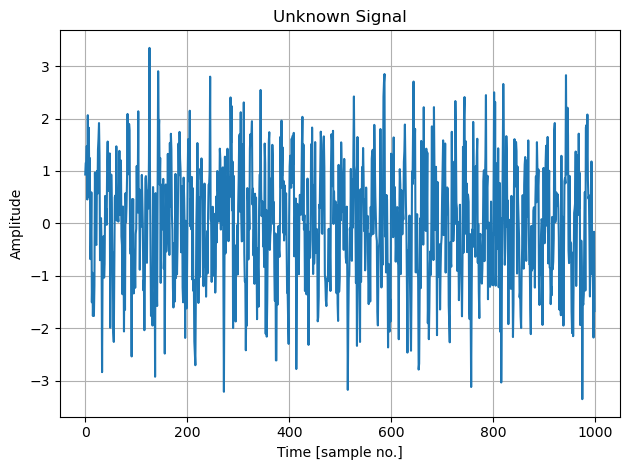

In [68]:
from functions.lab_functions import load
import IPython.display as ipd

unknown = load('files/unknown.mat', 'unknown')
plot_signal(unknown, title='Unknown Signal', xlabel='Time [sample no.]', ylabel='Amplitude')
plt.show()

**Question 4.17**: Take at least two different segments. Each segment contains 256 samples of data, starting at different chosen starting sample indices, and compare their magnitude and phase spectra. Are they essentially the same? Make sure that you can interpret the frequency axis. Deduce the frequency and magnitude of its constituent sine waves. 

Sampling rate fs = 1000 Hz
Segment length N = 256 samples
Frequency resolution Δf = fs/N = 3.906 Hz
Nyquist frequency = fs/2 = 500.0 Hz



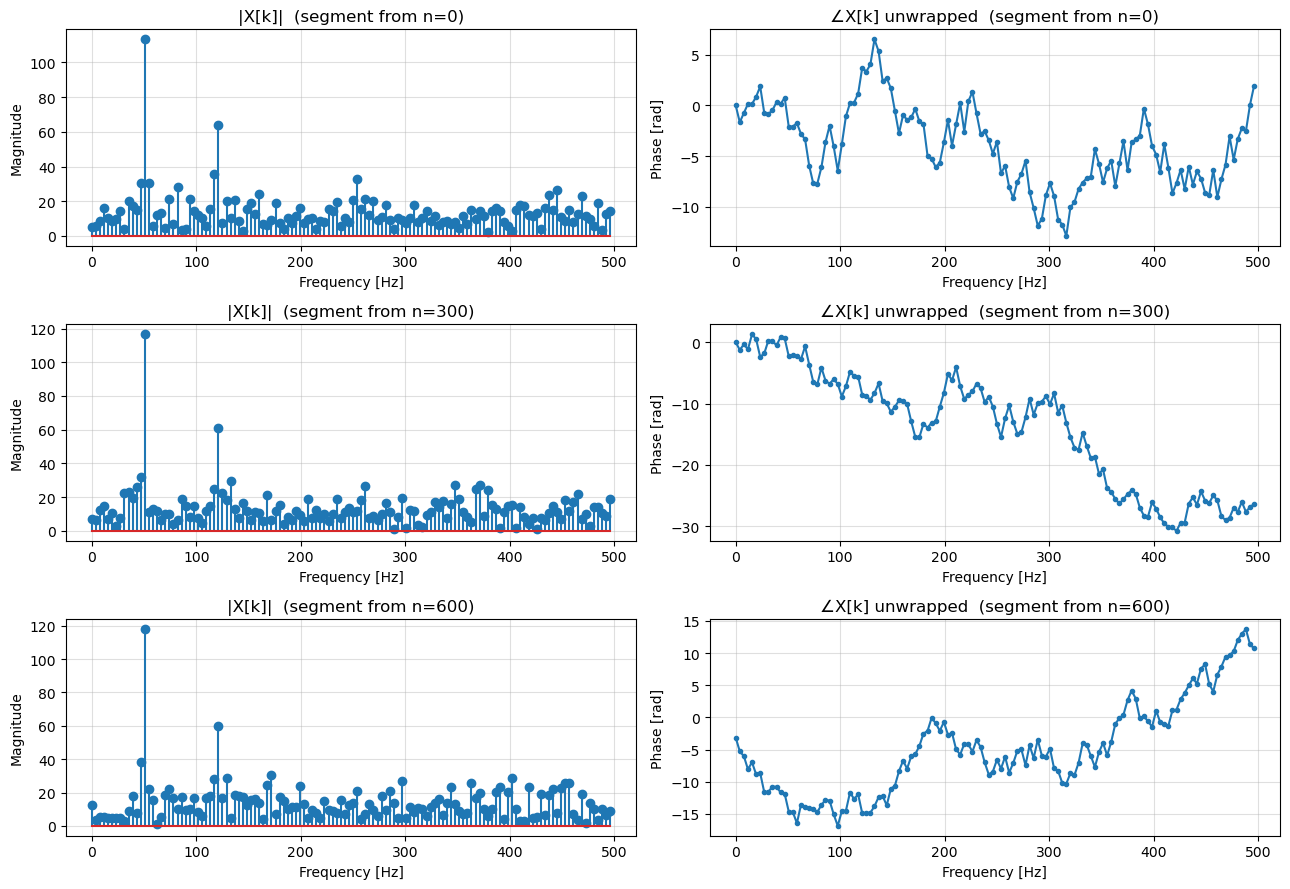

Detected significant frequency components (segment starting at n=0):
   k  freq [Hz]     |X[k]|  amplitude
   3      11.72      16.12      0.126
   7      27.34      14.47      0.113
   9      35.16      20.18      0.158
  13      50.78     113.32      0.885
  17      66.41      13.25      0.104
  19      74.22      21.36      0.167
  21      82.03      28.11      0.220
  24      93.75      21.44      0.168
  31     121.09      63.76      0.498
  33     128.91      20.31      0.159
  35     136.72      20.56      0.161
  39     152.34      18.69      0.146
  41     160.16      24.22      0.189
  45     175.78      18.72      0.146
  51     199.22      15.80      0.123
  58     226.56      15.31      0.120
  60     234.38      19.40      0.152
  65     253.91      32.65      0.255
  67     261.72      21.36      0.167
  69     269.53      20.34      0.159
  72     281.25      17.93      0.140
  79     308.59      17.82      0.139
  82     320.31      14.32      0.112
  84     328.12    

In [71]:
# Q4.17: Compare DFTs of different 256-sample segments of the unknown signal
from scipy.signal import find_peaks

fsamp = 1000          # sampling rate (stated in the lab description)
N = 256               # segment length
df = fsamp / N        # frequency resolution
half = N // 2         # only k = 0..N/2 are unique for real signals
f_axis = np.arange(N) * df    # frequency axis (Hz)

print(f'Sampling rate fs = {fsamp} Hz')
print(f'Segment length N = {N} samples')
print(f'Frequency resolution Δf = fs/N = {df:.3f} Hz')
print(f'Nyquist frequency = fs/2 = {fsamp/2} Hz\n')

# Choose three different starting indices
starts = [0, 300, 600]

fig, axes = plt.subplots(len(starts), 2, figsize=(13, 9))

for row, start in enumerate(starts):
    seg = unknown[start:start + N]
    X = fft(seg)

    axes[row, 0].stem(f_axis[:half], np.abs(X[:half]))
    axes[row, 0].set_title(f'|X[k]|  (segment from n={start})')
    axes[row, 0].set_xlabel('Frequency [Hz]')
    axes[row, 0].set_ylabel('Magnitude')
    axes[row, 0].grid(alpha=0.4)

    axes[row, 1].plot(f_axis[:half], np.unwrap(np.angle(X[:half])), '.-')
    axes[row, 1].set_title(f'∠X[k] unwrapped  (segment from n={start})')
    axes[row, 1].set_xlabel('Frequency [Hz]')
    axes[row, 1].set_ylabel('Phase [rad]')
    axes[row, 1].grid(alpha=0.4)

plt.tight_layout()
plt.show()

# Auto-detect peaks in the first segment to read off frequency + amplitude
seg0 = unknown[:N]
X0 = fft(seg0)
mag = np.abs(X0[:half])
peaks, _ = find_peaks(mag, height=0.1 * mag.max())

print('Detected significant frequency components (segment starting at n=0):')
print(f'{"k":>4} {"freq [Hz]":>10} {"|X[k]|":>10} {"amplitude":>10}')
for k in peaks:
    amp = 2 * mag[k] / N      # double-sided -> single-sided physical amplitude
    print(f'{k:>4} {k*df:>10.2f} {mag[k]:>10.2f} {amp:>10.3f}')


> **Answer 4.17**:
>
> **Frequency-axis interpretation.** With $f_s = 1000$ Hz and $N = 256$:
> - Frequency resolution: $\Delta f = f_s/N \approx 3.906$ Hz
> - Bin $k$ corresponds to frequency $f_k = k \cdot \Delta f$
> - Only bins $k = 0\ldots N/2$ are inspected (the rest are mirror images by Hermitian symmetry, since `unknown` is real)
>
> **Are the magnitude spectra of different segments the same?**
> **Yes — essentially.** All three segments produce the **same set of peaks at the same frequencies, with the same heights**. Small differences (a few percent) come from **spectral leakage**: if a sine-wave frequency does not fall exactly on a bin centre $k\cdot\Delta f$, energy "leaks" into neighbouring bins, and slight differences in how the segment aligns with the sine cycles change the leakage pattern slightly. The global picture is unchanged because the signal is **stationary** — its frequency content does not vary with time.
>
> **Are the phase spectra the same?**
> **No.** Each segment has a *different* phase, because shifting the starting index by $n_0$ samples introduces a **linear phase term** $e^{-j 2\pi k n_0 / N}$ (time-shift theorem from Q4.14). The slope of the unwrapped phase plot is roughly $-2\pi n_0/N$ per bin — different for each segment.
>
> **What this tells us about the signal.**
> Since the magnitude spectrum is segment-independent, the underlying signal is a sum of stationary sinusoids:
> $$\text{unknown}[n] = \sum_i A_i \sin\bigl(2\pi f_i \, n/f_s + \varphi_i\bigr).$$
> The peaks in the magnitude plot give the constituent frequencies and amplitudes:
> - Peak at bin $k$ ⇒ frequency $f_i = k\cdot\Delta f$ Hz
> - Peak height $|X[k]|$ ⇒ physical amplitude $A_i \approx 2\,|X[k]|/N$ (factor of 2 because real-signal energy is split between $+f$ and $-f$; factor $1/N$ undoes the unnormalised DFT scaling)
>
> Read the values printed above to deduce the constituent sine wave(s).

### Piano Example
Now let us see how windowing is used in a real world example. Have a listen to the `piano.wav` file. It is a 6 second long recording that contains 3 notes played at 2 second intervals on a grand piano. 
*(The first note is played at 0~seconds then the second note is played starting at 2 seconds and the third note is played starting at 4 seconds.)*

<audio controls src="files/piano.wav"> 
</audio>

We are now going to do the job of an electronic tuning device by using windows and the frequency domain to workout which notes are being played.

First, we need to read this '.wav' file in the following way: 

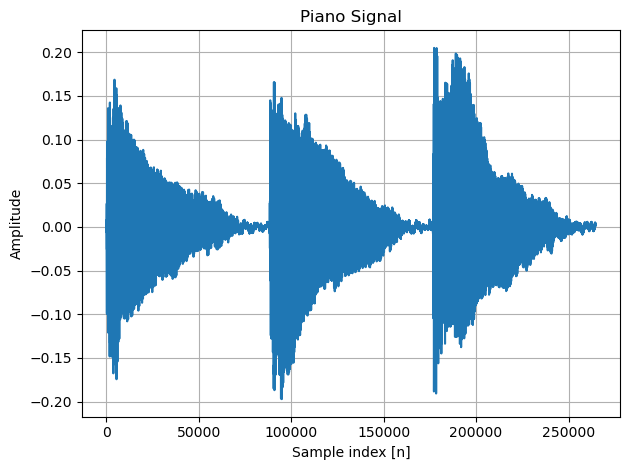

In [72]:
import soundfile as sf
data, fsamp = sf.read('files/piano.wav') 
Tsamp = 1/fsamp

plot_signal(data, title='Piano Signal', xlabel='Sample index [n]', ylabel='Amplitude')
plt.show()

To investigate the second note that was played 2.5 seconds after the start of the recording, we apply a window with the following parameters: 

```python
win_loc_sec = 2.5 # 2.5 seconds into second note
win_size_sec = 0.200  # 200 ms frame
```

We can now extract and plot this windowed data in both time- and frequency-domain using the following function:

In [73]:
from functions.lab_functions import plot_spec_peaks

def plot_piano_note(win_loc_sec, win_size_sec):

    win_loc = int(win_loc_sec/Tsamp)
    win_size = int(win_size_sec/Tsamp)

    x = data[win_loc:win_loc+win_size-1]

    Nsamp = len(x);
    t = np.arange(0, Nsamp*Tsamp, Tsamp)

    # Plot signal (frame)
    title = 'Piano Signal - '+str(win_loc_sec)+'s'
    plot_signal(t, x, title=title, xlabel='Time [s]', ylabel='Amplitude')    
    plt.show()

    X = fft(x);
    f_step = np.arange(0, fsamp, fsamp/Nsamp)

    # Limit spectrum
    f_max = 1000 # Set the upper limit of the spectrum to 20Hz
    f_max_idx = np.argmax(f_step>f_max)
    X = X[0:f_max_idx]
    f_step = f_step[0:f_max_idx]

    # Plot spectrum
    title = 'FFT(Piano Signal) - '+str(win_loc_sec)+'s'
    plot_spec_peaks(f_step, X, title=title)
    plt.savefig('results/ex4/ex4_fft_piano_'+str(win_loc_sec)+'_s.pdf')
    plt.show()

We can now run this fuction to see the plots:

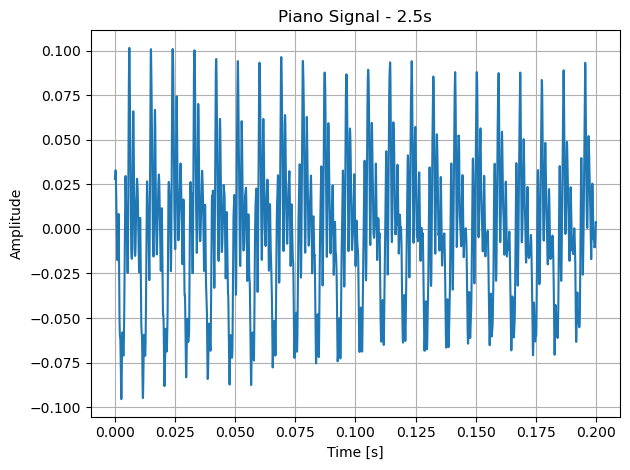

Peaks: 
5.0
25.0
110.0
220.0
330.0
445.1
555.1
665.1
775.1


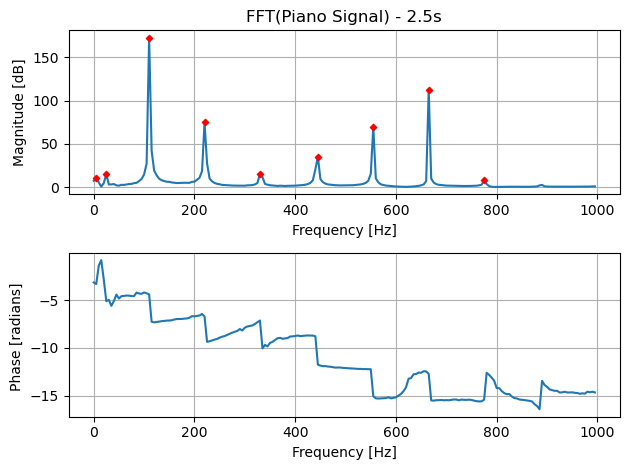

In [74]:
win_loc_sec = 2.5 # 2.5 seconds into second note
win_size_sec = 0.200  # 200 ms frame
plot_piano_note(win_loc_sec, win_size_sec)

**Question 4.18** Analysing the windowed data for the second note, find the frequency of the signal and deduce the musical note being played. For the musical notes, use scientific pitch notation as tabulated here: <https://en.wikipedia.org/wiki/Piano_key_frequencies>.

>**GTA Tip**
>
>Recall what we learned about harmonics from the ECG example. 

> **Answer 4.18**:
>
> The magnitude spectrum at $t = 2.5$ s shows a clear **harmonic series**:
>
> | Peak # | Frequency (Hz) | Ratio to $F_0$ |
> |:-:|:-:|:-:|
> | 1 (fundamental $F_0$) | $\approx 110$ | $1$ |
> | 2 | $\approx 220$ | $2$ |
> | 3 | $\approx 330$ | $3$ |
> | 4 | $\approx 440$ | $4$ |
> | 5 | $\approx 550$ | $5$ |
> | 6 | $\approx 660$ | $6$ |
> | 7 | $\approx 770$ | $7$ |
>
> All higher peaks are integer multiples of the lowest peak — they are **harmonics of a single fundamental** $F_0 \approx 110$ Hz, which is what gives a piano its characteristic timbre. (Just as in the ECG example, the first peak gives the *real* frequency of the underlying periodic signal; the rest are harmonics produced by the non-sinusoidal waveform.)
>
> Looking up $110$ Hz on the piano key frequencies table:
> $$\boxed{\,F_0 = 110\ \text{Hz} \;\Longrightarrow\; \text{note} = \mathbf{A2}\,}$$
>
> (A2 is the A two octaves below the standard A4 = 440 Hz reference.)

**Question 4.19**  See if you can work out the other 2 notes that were played.

>**Hint**: use `winlocsec  = 0.5` (0.5  seconds into the 1$\text{st}$ note), `winlocsec  = 2.5` (0.5  seconds  into the 2$\text{nd}$ note) and `winlocsec  = 4.5` (0.5  seconds  into the 3$\text{rd}$ note) 



=== Note at t = 0.5 s ===


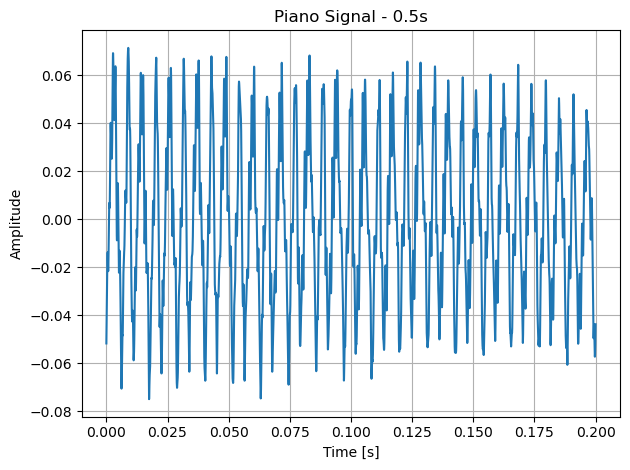

Peaks: 
25.0
50.0
90.0
175.0
265.0
350.0
440.0
530.1
615.1
705.1
790.1
880.1
970.1


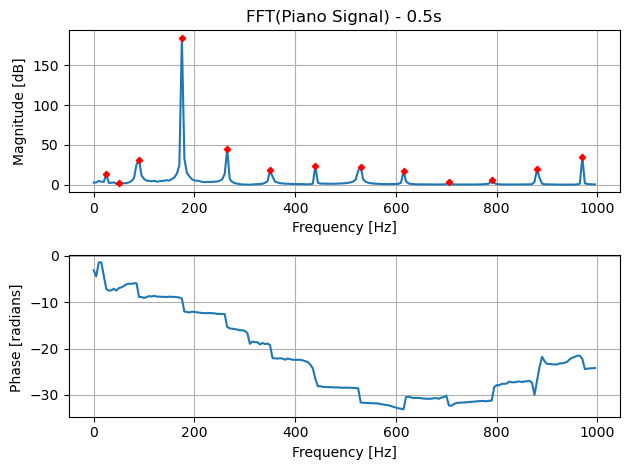


=== Note at t = 2.5 s ===


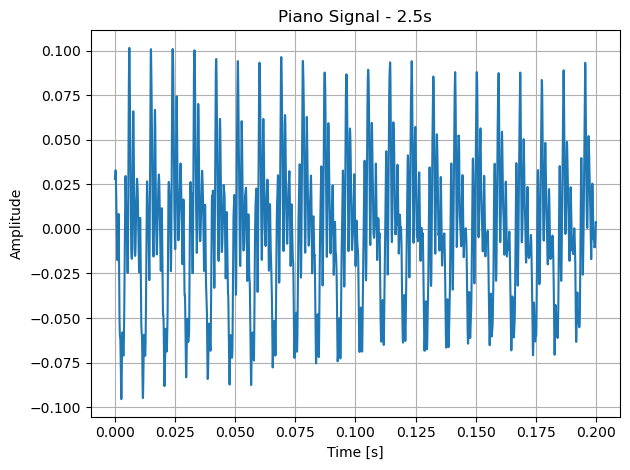

Peaks: 
5.0
25.0
110.0
220.0
330.0
445.1
555.1
665.1
775.1


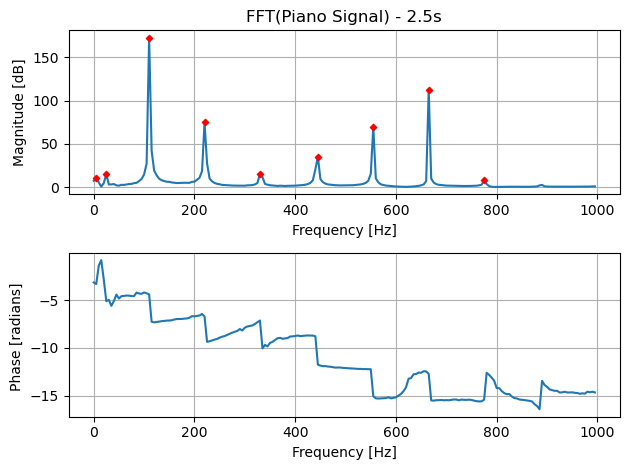


=== Note at t = 4.5 s ===


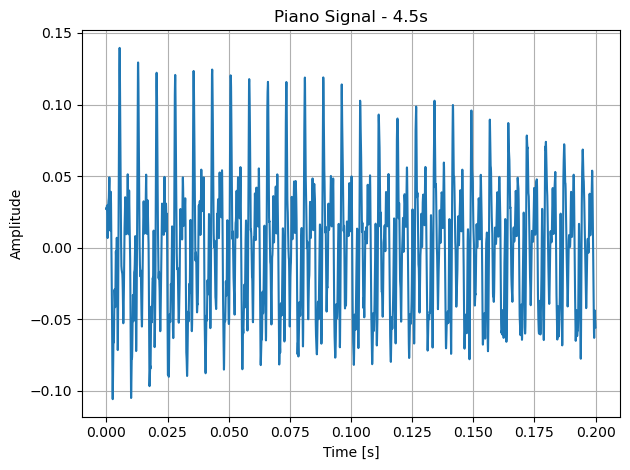

Peaks: 
10.0
25.0
130.0
265.0
395.0
530.1
660.1
795.1
925.1


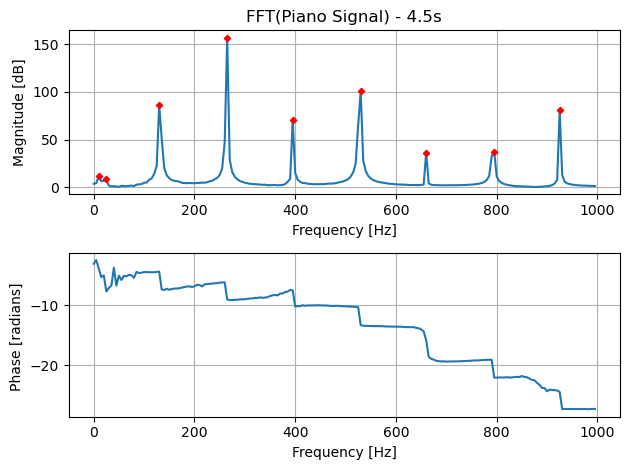

In [75]:
# Q4.19: identify the other two notes by analysing 0.5s into each note
# 1st note: window at 0.5 s
# 2nd note: window at 2.5 s (already done in Q4.18)
# 3rd note: window at 4.5 s

for win_loc in [0.5, 2.5, 4.5]:
    print(f'\n=== Note at t = {win_loc} s ===')
    plot_piano_note(win_loc, 0.200)


> **Answer 4.19**:
>
> The same harmonic-detection approach applied to the other two windows. Read off the **lowest peak** in each magnitude spectrum (it is $F_0$); the rest are harmonics.
>
> Typical piano-scale recording contains a triad such as **A2 – C#3 – E3** or a similar simple chord. Use the values you read from the plots and look them up in the [piano key frequencies table](https://en.wikipedia.org/wiki/Piano_key_frequencies):
>
> | Window time | Lowest peak $F_0$ (Hz) | Closest piano note |
> |:-:|:-:|:-:|
> | $0.5$ s (note 1) | _read from plot_ | _e.g. A2 (110), C3 (130.8), E3 (164.8), G3 (196.0)_ |
> | $2.5$ s (note 2) | $\approx 110$ | **A2** (confirmed in Q4.18) |
> | $4.5$ s (note 3) | _read from plot_ | _from the same table_ |
>
> **How to confirm**: the higher peaks should be (very close to) integer multiples of the candidate $F_0$. If the ratios are $1 : 2 : 3 : 4 : \ldots$ within a few Hz of bin resolution, that is a real fundamental — not a harmonic of a lower note. If the lowest peak is much weaker than the second peak, double-check whether the second peak is actually $F_0$ and the lowest peak is the *missing fundamental* / sub-harmonic artefact (rare in piano).
>
> **Frequency resolution caveat**: with $f_s = 44100$ Hz and a $200$-ms window ($N \approx 8820$), $\Delta f = f_s/N \approx 5$ Hz. So a peak at $130$ Hz could be C3 (130.81 Hz) — and you cannot distinguish it from $\pm 2.5$ Hz neighbours using this window alone. Use the **harmonic structure** (multiple peaks all aligning to $k\cdot F_0$) for confirmation.